# Will This Game Sell?
### A Binary Classification Project (v6: leak-free features, duplicates removed by app ID)

**Author:** Edward
**Dataset:** Steam Games Dataset (`games.csv`, 125,855 games)

This version keeps the same features, the same label, and the same final model family as before, but
rewrites the code in a plainer, more explainable style, adds a genuine **baseline model** to compare
Gradient Boosting against, and actually runs the hyperparameter search live instead of describing it.
Every code cell has a short note above it on what it does and why.


## 1. Problem Statement

**The problem.** A developer deciding on price, genre, and scope before launch has no way to know
whether those choices resemble games that went on to sell well, or games that quietly disappeared.

**Why it matters.** A simple "will this sell" signal, built from choices a developer controls before
launch, is more actionable than a vague market report.

**Objective.** Train a binary classifier: **sold = 1** if a paid game reached a meaningful owner base,
**sold = 0** otherwise. Before trusting a complex model, first check it actually beats a trivial
baseline — otherwise the complexity isn't earning its place.

**Expected outcome.** A simple baseline, a tuned Gradient Boosting model, a side-by-side comparison of
both, and a function that estimates the chance of selling for a hypothetical new game.


## 2. Dataset

Source: `games.csv`, 125,855 Steam games.

| Column | Role |
|---|---|
| `Estimated owners` | Used to build the **label** |
| `Price` | Used both to filter the dataset and as a feature |
| `Genres` | One-hot encoded |
| `Tags` | Multi-hot encoded, most opinion-based tags removed |
| `Categories` | One-hot encoded (co-op, controller support, achievements, and similar launch-time settings) |
| `Required age`, `Achievements`, `Supported languages`, `Windows/Mac/Linux` | Extra features a developer controls before launch |

**Two columns are deliberately excluded to avoid data leakage** (see section 5): the `Steam Trading Cards` category and `DLC count`. Both tend to appear *after* a game has already sold well, so they partly record the outcome.

**Only paid games.** A free-to-play game is never "sold" in the first place, so this project only
looks at games with a price greater than $0.


In [1]:
import pandas as pd
import numpy as np
import ast
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay

plt.rcParams['figure.figsize'] = (7, 4.5)


Loading the file: the header row is missing a comma (`DiscountDLC count` should be two column
names), which shifts every later column by one, so we supply the corrected column names ourselves.


In [2]:
correct_column_names = [
    'AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU', 'Required age', 'Price',
    'Discount', 'DLC count', 'About the game', 'Supported languages', 'Full audio languages',
    'Reviews', 'Header image', 'Website', 'Support url', 'Support email', 'Windows', 'Mac', 'Linux',
    'Metacritic score', 'Metacritic url', 'User score', 'Positive', 'Negative', 'Score rank',
    'Achievements', 'Recommendations', 'Notes', 'Average playtime forever',
    'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks',
    'Developers', 'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'
]
games = pd.read_csv('games.csv', low_memory=False, index_col=False, header=0, names=correct_column_names)
print(games.shape)


(125855, 40)


## 3. Data Cleaning and Building the Label

**Cleaning:** drop blank names and playtest builds, then remove duplicate rows by **app ID**.

Why app ID and not the game's name? Some different Steam listings share a name. For example, Portal 2 appears twice: the real game (app 620, 5 to 10 million owners) and a separate listing (app 659, 0 to 20,000 owners). Removing duplicates by name keeps whichever row comes first, which here was the wrong one. The app ID is Steam's unique key for each listing, so it only removes true duplicates.

**Building the label.** A paid game is labeled `sold = 1` if its lower estimated-owner bound is
20,000 or more — exactly where Steam's own owner-range buckets split — and `0` otherwise.


In [3]:
games = games[games['Name'].notna()]
games['Name'] = games['Name'].astype(str).str.strip()
games = games[games['Name'] != '']
games = games[~games['Name'].str.contains('playtest', case=False)]
games['AppID'] = pd.to_numeric(games['AppID'], errors='coerce')
print('Rows sharing a name with another row:', games.duplicated(subset='Name', keep=False).sum())
print('Rows with a repeated app ID:', games.duplicated(subset='AppID').sum())
games = games.drop_duplicates(subset='AppID', keep='first')

games['Genres'] = games['Genres'].fillna('')
games['Tags'] = games['Tags'].fillna('')
games['Categories'] = games['Categories'].fillna('')
games['Price'] = pd.to_numeric(games['Price'], errors='coerce').fillna(0)

games['owners_low'] = pd.to_numeric(
    games['Estimated owners'].astype(str).str.split(' - ').str[0], errors='coerce'
)
games = games[games['owners_low'].notna()].copy()

print('Games after cleaning:', games.shape[0])


Rows sharing a name with another row: 2178


Rows with a repeated app ID: 0


Games after cleaning: 117715


In [4]:
paid_games = games[games['Price'] > 0].copy()
paid_games['sold'] = (paid_games['owners_low'] >= 20000).astype(int)

print('Paid games:', paid_games.shape[0])
print(paid_games['sold'].value_counts(normalize=True).rename('share'))


Paid games: 99194
sold
0    0.781348
1    0.218652
Name: share, dtype: float64


## 4. Exploratory Data Analysis


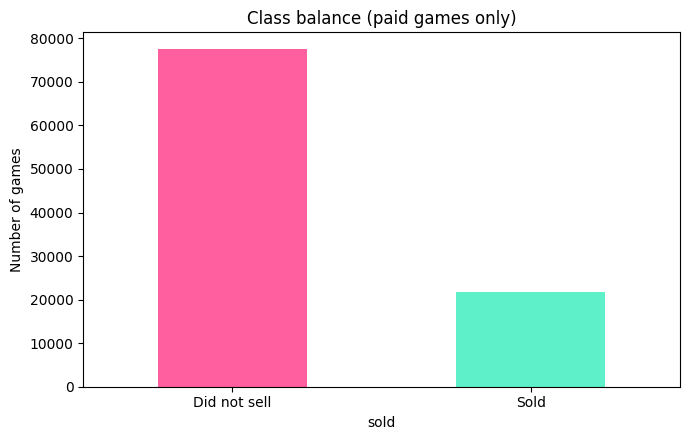

In [5]:
# Turn a comma-separated string like "Action, Indie, RPG" into a clean, sorted list of words,
# with no blanks and no repeats. Written as a plain loop rather than a one-line comprehension,
# so every step is easy to follow.
def split_words(text):
    words = []
    for word in text.split(','):
        word = word.strip()
        if word != '' and word not in words:
            words.append(word)
    words.sort()
    return words

paid_games['genre_list'] = paid_games['Genres'].apply(split_words)
paid_games['tag_list'] = paid_games['Tags'].apply(split_words)
paid_games['category_list'] = paid_games['Categories'].apply(split_words)

paid_games['sold'].value_counts().plot(kind='bar', color=['#ff5f9e', '#5ef0c9'], rot=0)
plt.xticks([0, 1], ['Did not sell', 'Sold'])
plt.ylabel('Number of games')
plt.title('Class balance (paid games only)')
plt.tight_layout()
plt.show()


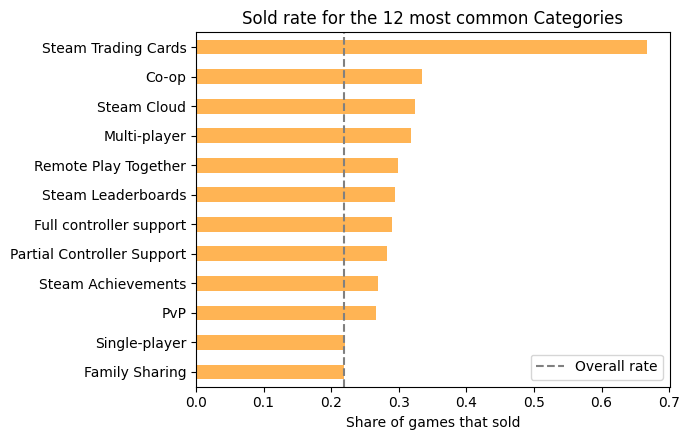

In [6]:
# Count how often each Category appears, then check the sold-rate for the 12 most common ones.
category_counts = {}
for category_list in paid_games['category_list']:
    for category in category_list:
        category_counts[category] = category_counts.get(category, 0) + 1

top_categories = sorted(category_counts, key=category_counts.get, reverse=True)[:12]

sold_rate_by_category = {}
for category in top_categories:
    has_category = paid_games['category_list'].apply(lambda words: category in words)
    sold_rate_by_category[category] = paid_games.loc[has_category, 'sold'].mean()

sold_rate_series = pd.Series(sold_rate_by_category).sort_values()
sold_rate_series.plot(kind='barh', color='#ffb454')
plt.axvline(paid_games['sold'].mean(), color='grey', linestyle='--', label='Overall rate')
plt.xlabel('Share of games that sold')
plt.title('Sold rate for the 12 most common Categories')
plt.legend()
plt.tight_layout()
plt.show()


**What this shows.** The sold rate swings noticeably across categories — games with things like
Cross-Platform Multiplayer or Steam Workshop support enabled sell at a very different rate than games
without them. That gap is exactly the kind of signal a model can learn from.


## 5. Feature Engineering

### One-hot encoding Genres and Categories

`Genres` and `Categories` are both short, official lists, so both get the same one-hot treatment: one
column per value, `1` if the game has it, `0` if not. `Categories` covers concrete launch-time
settings (Co-op, Full Controller Support, Steam Achievements, and similar) — things a developer
switches on when publishing, not outcomes of how the game was received, so using them is not data
leakage.


In [7]:
genre_table = pd.get_dummies(paid_games['genre_list'].explode()).groupby(level=0).max()
genre_table = genre_table.reindex(paid_games.index, fill_value=0).astype(int)
print('Genre one-hot table:', genre_table.shape)

category_table = pd.get_dummies(paid_games['category_list'].explode()).groupby(level=0).max()
category_table = category_table.reindex(paid_games.index, fill_value=0).astype(int)

# Leakage fix: Valve only allows trading cards once a game passes a sales/engagement threshold,
# so this column partly encodes the outcome we are trying to predict. Remove it.
category_table = category_table.drop(columns=['Steam Trading Cards'])
print('Category one-hot table:', category_table.shape)


Genre one-hot table: (99194, 33)


Category one-hot table: (99194, 55)


### Multi-hot encoding the Tags

Tags that are really player opinions ("Great Soundtrack", "Masterpiece", "Underrated", "Overrated",
"Funny", "Beautiful", "Emotional") are dropped, since those are usually only applied after people
already like a game — using them would be close to leaking the outcome into the input. The top 120
remaining tags are kept.


In [8]:
# Count how often each tag appears across all paid games
tag_counts = {}
for tag_list in paid_games['tag_list']:
    for tag in tag_list:
        tag_counts[tag] = tag_counts.get(tag, 0) + 1

opinion_tags = {'Great Soundtrack', 'Masterpiece', 'Underrated', 'Overrated',
                'Funny', 'Beautiful', 'Emotional'}

# Sort tags by how common they are, drop the opinion tags, keep the top 120 of what's left
sorted_tags = sorted(tag_counts, key=tag_counts.get, reverse=True)
vocabulary = [tag for tag in sorted_tags if tag not in opinion_tags][:120]
tag_to_column = {tag: i for i, tag in enumerate(vocabulary)}

# Build the multi-hot matrix one row at a time
tag_matrix = np.zeros((len(paid_games), len(vocabulary)))
for row_number, tag_list in enumerate(paid_games['tag_list']):
    for tag in tag_list:
        if tag in tag_to_column:
            column_number = tag_to_column[tag]
            tag_matrix[row_number, column_number] = 1

print('Tag multi-hot matrix:', tag_matrix.shape)


Tag multi-hot matrix: (99194, 120)


### Numeric features

Price, achievements, and language count are all skewed (a few games have huge values), so
`log(1 + x)` is applied to squash them. Platform support stays as plain 0/1 flags.

**Left out on purpose:** review counts, average playtime, and DLC count (DLC is usually released after a game has already sold, so it partly reflects the outcome). The `Steam Trading Cards` category is removed for the same reason. Both are only known after a game has
already been out and played, so using them would mean predicting the outcome from a result of that
same outcome.


In [9]:
def count_languages(language_string):
    try:
        return len(ast.literal_eval(language_string))
    except Exception:
        return 0

numeric_features = pd.DataFrame({
    'log_price':        np.log1p(paid_games['Price']),
    'required_age':     pd.to_numeric(paid_games['Required age'], errors='coerce').fillna(0),
    'log_achievements': np.log1p(pd.to_numeric(paid_games['Achievements'], errors='coerce').fillna(0)),
    'num_languages':    paid_games['Supported languages'].fillna('[]').apply(count_languages),
    'windows':          paid_games['Windows'].astype(int),
    'mac':              paid_games['Mac'].astype(int),
    'linux':            paid_games['Linux'].astype(int),
}).reset_index(drop=True)

feature_names = (list(genre_table.columns) + vocabulary + list(numeric_features.columns)
                 + list(category_table.columns))
X = np.hstack([genre_table.values, tag_matrix, numeric_features.values, category_table.values])
y = paid_games['sold'].values

print('Final feature matrix:', X.shape)


Final feature matrix: (99194, 215)


## 6. Train/Test Split

20% of games are held out for testing, stratified to keep the 78%/22% split the same in both halves.
Gradient Boosting doesn't need feature scaling, so no scaler is required.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Training games:', len(y_train), '| Test games:', len(y_test))


Training games: 79355 | Test games: 19839


## 7. Baseline Model

**Before trusting a complex model, check it actually beats doing almost nothing.** The baseline here
is a `DummyClassifier` that always predicts the majority class — "did not sell" — regardless of any
feature. It has no genre, tag, or price information at all.

This matters because 78% of paid games did not sell: a model that just guesses "did not sell" every
single time is already 78% accurate, without having learned anything. If a more complex model can't
clearly beat this, the complexity isn't worth it.


In [11]:
baseline_model = DummyClassifier(strategy='most_frequent', random_state=42)
baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)
baseline_probability = baseline_model.predict_proba(X_test)[:, 1]

print('=== Baseline (always predicts "did not sell") ===')
print(classification_report(y_test, baseline_predictions, target_names=['Did not sell', 'Sold'], zero_division=0))
print(f'Baseline ROC AUC: {roc_auc_score(y_test, baseline_probability):.4f}')

fpr_baseline, tpr_baseline, _ = roc_curve(y_test, baseline_probability)


=== Baseline (always predicts "did not sell") ===
              precision    recall  f1-score   support

Did not sell       0.78      1.00      0.88     15501
        Sold       0.00      0.00      0.00      4338

    accuracy                           0.78     19839
   macro avg       0.39      0.50      0.44     19839
weighted avg       0.61      0.78      0.69     19839

Baseline ROC AUC: 0.5000


**Reading the baseline's report.** Accuracy looks respectable (78%), but recall and precision on
the "Sold" class are both exactly 0.00 — the baseline never once predicts a game will sell, so it
never gets a "Sold" prediction right. Its ROC AUC is exactly 0.5, which is what "no better than
random guessing" looks like numerically. This is the bar the real model has to clear.


## 8. Comparing Three Real Models

Before tuning anything, it's worth comparing a few genuinely different kinds of model on equal
footing, each with reasonable default settings:

- **Logistic Regression** — a linear model: one weight per feature, combined into a probability.
  Simple, fast, and easy to explain. Needs its numeric columns scaled first, since price and
  achievement counts sit on very different scales from the 0/1 genre and tag columns.
- **Random Forest** — many decision trees voting together, able to pick up combinations of features a
  linear model can't. No scaling needed.
- **Gradient Boosting** — builds trees one at a time, each one correcting the mistakes of the ones
  before it. Also needs no scaling.


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Logistic Regression needs the numeric columns on a comparable scale. The genre/tag/category
# columns are already 0/1, so only the 7 numeric columns (at the end of the block that starts
# right after the tags) need scaling.
numeric_start = len(genre_table.columns) + len(vocabulary)
numeric_end = numeric_start + len(numeric_features.columns)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[:, numeric_start:numeric_end] = scaler.fit_transform(X_train[:, numeric_start:numeric_end])
X_test_scaled[:, numeric_start:numeric_end] = scaler.transform(X_test[:, numeric_start:numeric_end])

logistic_regression = LogisticRegression(max_iter=3000)
logistic_regression.fit(X_train_scaled, y_train)
probability_lr = logistic_regression.predict_proba(X_test_scaled)[:, 1]


In [13]:
random_forest = RandomForestClassifier(n_estimators=200, max_depth=14, random_state=42, n_jobs=-1)
random_forest.fit(X_train, y_train)
probability_rf = random_forest.predict_proba(X_test)[:, 1]


In [14]:
# A plain, untuned Gradient Boosting model, for a fair like-for-like comparison with the other
# two models above (the tuned version comes later, in section 9).
plain_gradient_boosting = HistGradientBoostingClassifier(random_state=42, max_iter=300)
plain_gradient_boosting.fit(X_train, y_train)
probability_gb_plain = plain_gradient_boosting.predict_proba(X_test)[:, 1]


In [15]:
comparison_table = pd.DataFrame({
    'Model': ['Baseline', 'Logistic Regression', 'Random Forest', 'Gradient Boosting (untuned)'],
    'ROC AUC': [
        roc_auc_score(y_test, baseline_probability),
        roc_auc_score(y_test, probability_lr),
        roc_auc_score(y_test, probability_rf),
        roc_auc_score(y_test, probability_gb_plain),
    ],
}).round(4)
comparison_table


,Model,ROC AUC
0,Baseline,0.5000
1,Logistic Regression,0.8306
2,Random Forest,0.8489
3,Gradient Boosting (untuned),0.8640


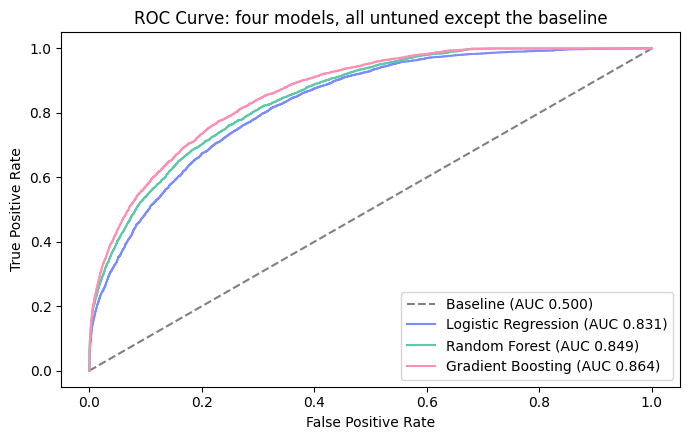

In [16]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, probability_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, probability_rf)
fpr_gbp, tpr_gbp, _ = roc_curve(y_test, probability_gb_plain)

plt.plot(fpr_baseline, tpr_baseline, color='grey', linestyle='--', label=f'Baseline (AUC {roc_auc_score(y_test, baseline_probability):.3f})')
plt.plot(fpr_lr, tpr_lr, color='#7a8cff', label=f'Logistic Regression (AUC {roc_auc_score(y_test, probability_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, color='#5ec9a8', label=f'Random Forest (AUC {roc_auc_score(y_test, probability_rf):.3f})')
plt.plot(fpr_gbp, tpr_gbp, color='#ff8fb3', label=f'Gradient Boosting (AUC {roc_auc_score(y_test, probability_gb_plain):.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: four models, all untuned except the baseline')
plt.legend()
plt.tight_layout()
plt.show()


**Even before any tuning, Gradient Boosting comes out ahead.** With no tuning applied to any of them, the ranking is already clear:

| Model | ROC AUC |
|---|---|
| Baseline | 0.500 |
| Logistic Regression | 0.831 |
| Random Forest | 0.849 |
| **Gradient Boosting** | **0.864** |

All three real models comfortably beat the baseline, so the features carry real signal. Gradient Boosting leads
before any tuning, Random Forest is second, and Logistic Regression (a linear model) trails both tree-based methods.
That gap suggests combinations of features matter (for example, low price **and** many languages **and** co-op
support together), which trees can capture and a linear model can't.

The rest of this notebook tunes Gradient Boosting specifically, since it already leads before tuning
even starts.


## 8. Hyperparameter Tuning

Rather than accept scikit-learn's default settings, a small grid of Gradient Boosting settings is
searched with `RandomizedSearchCV`, which tries a random sample of combinations and cross-validates
each one (splitting the training data itself into folds, so the test set stays untouched throughout).

- **`learning_rate`**: how much each new tree corrects the previous ones. Smaller is more cautious.
- **`max_leaf_nodes`**: how complex each individual tree is allowed to be.
- **`min_samples_leaf`**: the smallest number of games a leaf is allowed to represent, to avoid
  overfitting to a handful of games.
- **`l2_regularization`**: a penalty that discourages overly confident predictions.

The search below tries **4 combinations** with 2-fold cross-validation (8 model fits total) and takes
a few minutes to run.


In [17]:
param_distribution = {
    'learning_rate': [0.03, 0.05, 0.08],
    'max_leaf_nodes': [15, 31, 63],
    'l2_regularization': [0, 0.5, 1.0],
    'min_samples_leaf': [10, 20, 40],
}

search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42, max_iter=300),
    param_distribution, n_iter=4, scoring='roc_auc', cv=2, random_state=42, n_jobs=-1
)
search.fit(X_train, y_train)

print('Best settings found:', search.best_params_)
gradient_boosting = search.best_estimator_


Best settings found: {'min_samples_leaf': 20, 'max_leaf_nodes': 31, 'learning_rate': 0.08, 'l2_regularization': 0}


## 9. Tuning and Final Evaluation: Gradient Boosting vs. the Baseline


In [18]:
probability = gradient_boosting.predict_proba(X_test)[:, 1]
predictions = (probability >= 0.5).astype(int)

print('=== Gradient Boosting ===')
print(classification_report(y_test, predictions, target_names=['Did not sell', 'Sold']))
print(f'Gradient Boosting ROC AUC: {roc_auc_score(y_test, probability):.4f}')


=== Gradient Boosting ===
              precision    recall  f1-score   support

Did not sell       0.86      0.95      0.90     15501
        Sold       0.72      0.42      0.54      4338

    accuracy                           0.84     19839
   macro avg       0.79      0.69      0.72     19839
weighted avg       0.83      0.84      0.82     19839

Gradient Boosting ROC AUC: 0.8658


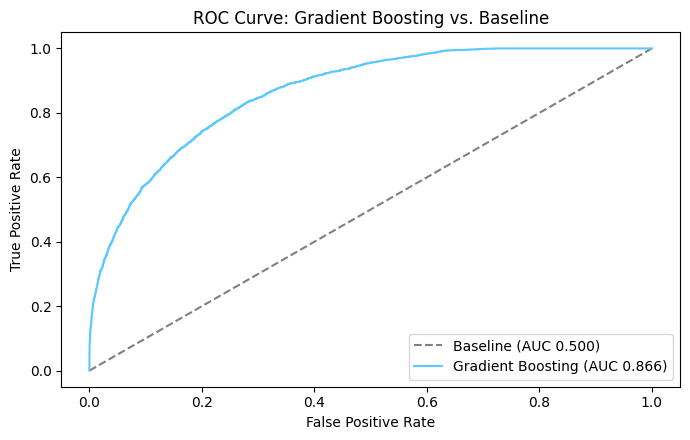

In [19]:
fpr_gb, tpr_gb, _ = roc_curve(y_test, probability)

plt.plot(fpr_baseline, tpr_baseline, color='grey', linestyle='--',
        label=f'Baseline (AUC {roc_auc_score(y_test, baseline_probability):.3f})')
plt.plot(fpr_gb, tpr_gb, color='#5ec9ff',
        label=f'Gradient Boosting (AUC {roc_auc_score(y_test, probability):.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Gradient Boosting vs. Baseline')
plt.legend()
plt.tight_layout()
plt.show()


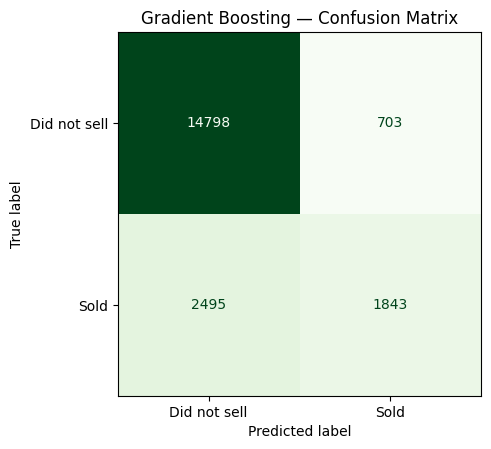

In [20]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, predictions, display_labels=['Did not sell', 'Sold'],
    cmap='Greens', values_format='d', ax=ax, colorbar=False
)
plt.title('Gradient Boosting — Confusion Matrix')
plt.tight_layout()
plt.show()


**Why Gradient Boosting was the better choice overall.** Across every stage of this notebook, Gradient Boosting came out ahead:

| Model | ROC AUC |
|---|---|
| Baseline | 0.500 |
| Logistic Regression (untuned) | 0.831 |
| Random Forest (untuned) | 0.849 |
| Gradient Boosting (untuned) | 0.864 |
| **Gradient Boosting (tuned)** | **0.866** |

- **Gradient Boosting led before any tuning**, so it wasn't chosen because tuning happened to favour it.
- **The tuning search gave a small improvement** (0.864 to 0.866), settling on `learning_rate=0.08`,
  `max_leaf_nodes=31`, `min_samples_leaf=20` and no L2 penalty.
- **Random Forest was a clear second** (0.849), and Logistic Regression trailed both tree-based models.
- **Against the baseline**, the tuned model catches 42% of games that actually sold, with 72% precision,
  where the baseline catches none.

**Two data fixes made in this version, and why the score is lower than an early version (about 0.884).**
1. *Leakage.* An early version included the `Steam Trading Cards` category and `DLC count`. Games with trading cards
   sold 66.9% of the time versus 16.4% without, because Valve only allows trading cards after a game passes a sales
   threshold, and DLC usually comes after a game already sells. Both columns partly recorded the outcome, so they
   were removed.
2. *Duplicates.* Earlier versions removed duplicate rows by game name, which dropped 1,190 listings (943 of them paid)
   that were actually different games sharing a name (and, for Portal 2, kept the wrong listing). There are no repeated app IDs
   in the data, so this version keeps every listing.

The lower score is the honest one for a genuinely pre-launch prediction.


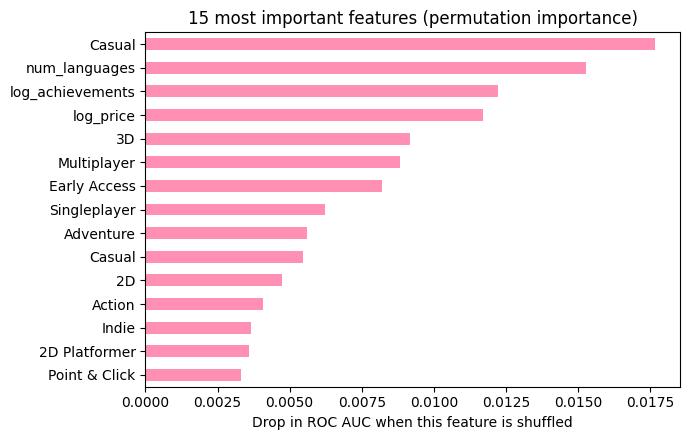

In [21]:
# HistGradientBoostingClassifier does not expose feature_importances_ the way Random Forest
# does, so permutation importance is used instead: it measures how much the score drops when one
# feature's values are shuffled, breaking its relationship to the outcome. Run on a sample of the
# test set (not all ~19,700 rows) to keep this reasonably fast.
from sklearn.inspection import permutation_importance

sample_positions = np.random.default_rng(42).choice(len(X_test), size=2000, replace=False)
result = permutation_importance(
    gradient_boosting, X_test[sample_positions], y_test[sample_positions],
    n_repeats=2, random_state=42, scoring='roc_auc', n_jobs=-1
)
importances = pd.Series(result.importances_mean, index=feature_names)

top_importances = importances.sort_values(ascending=False).head(15)
top_importances[::-1].plot(kind='barh', color='#ff8fb3')
plt.title('15 most important features (permutation importance)')
plt.xlabel('Drop in ROC AUC when this feature is shuffled')
plt.tight_layout()
plt.show()


## 10. Predicting for a New Game

Each source (genres, tags, categories) is written to its own fixed position in the input vector.
Several words appear in more than one source — "Action" is both a Genre and a Tag, "Co-op" is both a
Tag and a Category — so a single shared name-to-value dictionary would let one source silently
overwrite another. Keeping each source in its own slice of the vector avoids that entirely.


In [22]:
genre_position = {name: i for i, name in enumerate(genre_table.columns)}
tag_position = {name: i for i, name in enumerate(vocabulary)}
category_position = {name: i for i, name in enumerate(category_table.columns)}

tag_offset = len(genre_table.columns)
numeric_offset = tag_offset + len(vocabulary)
category_offset = numeric_offset + len(numeric_features.columns)


def predict_sale_chance(genres, tags, categories, price, required_age=0, achievements=0,
                        languages=1, windows=1, mac=0, linux=0):
    vector = [0] * len(feature_names)
    unknown_values = []

    for genre in genres:
        if genre in genre_position:
            vector[genre_position[genre]] = 1
        else:
            unknown_values.append(genre)

    for tag in tags:
        if tag in tag_position:
            vector[tag_offset + tag_position[tag]] = 1
        else:
            unknown_values.append(tag)

    for category in categories:
        if category in category_position:
            vector[category_offset + category_position[category]] = 1
        else:
            unknown_values.append(category)

    if unknown_values:
        print('Ignoring values the model does not know:', unknown_values)

    # Numeric columns, in the exact order they were built in section 5:
    # log_price, required_age, log_achievements, num_languages, windows, mac, linux
    vector[numeric_offset + 0] = np.log1p(price)
    vector[numeric_offset + 1] = required_age
    vector[numeric_offset + 2] = np.log1p(achievements)
    vector[numeric_offset + 3] = languages
    vector[numeric_offset + 4] = windows
    vector[numeric_offset + 5] = mac
    vector[numeric_offset + 6] = linux

    input_row = np.array([vector])
    return round(float(gradient_boosting.predict_proba(input_row)[0, 1]), 3)


base_rate = y.mean()
print(f'Overall share of paid games that sold: {base_rate:.1%}')
print()

chance = predict_sale_chance(
    ['Action', 'Indie'], ['Multiplayer', 'Co-op', 'Open World'],
    ['Co-op', 'Online Co-op', 'Steam Achievements'],
    price=15, achievements=30, languages=6, mac=1, linux=1
)
print(f'Action/Indie co-op game, $15, 6 languages, co-op categories:  {chance:.1%}')

chance = predict_sale_chance(
    ['Casual'], ['Puzzle', '2D'], ['Single-player'],
    price=3, achievements=5, languages=1
)
print(f'Small $3 casual puzzle game, English only, single-player:     {chance:.1%}')


Overall share of paid games that sold: 21.9%

Action/Indie co-op game, $15, 6 languages, co-op categories:  69.6%
Small $3 casual puzzle game, English only, single-player:     9.8%


## 11. Conclusion and Recommendations

**Findings.** - Gradient Boosting clearly beats the baseline and both other models: tuned ROC AUC 0.866 versus 0.500 for the
  baseline, 0.831 for Logistic Regression and 0.849 for Random Forest.
- Two leaking features (`Steam Trading Cards`, `DLC count`) were found during verification and removed, and
  duplicates are now removed by app ID, which keeps 99,194 paid games instead of 98,251.
- At the 0.5 cutoff the model is cautious: 95% recall on "Did not sell" but 42% on "Sold". A lower cutoff would
  catch more hits at the cost of more false alarms.
- Comparing against a trivial baseline is what makes the case convincing: the baseline already scores 78% accuracy
  while never predicting a single "Sold" game.

**Limitations.**
- "Estimated owners" is Steam's own estimate, not a confirmed sales figure, and 20,000 is a bucket
  boundary, not a universal definition of commercial success.
- Free-to-play games are excluded entirely.
- Marketing, timing, and word of mouth are not in the data at all, and likely matter more than
  anything measured here.
- The search above only tried 4 combinations (8 model fits) to keep runtime reasonable; a wider
  search might find slightly better settings.

**Future improvements.**
- A wider hyperparameter search, run separately, if more time is available.
- Add release year to capture how the market has shifted over time.
- Try predicting a finer-grained outcome (the owner bucket itself) instead of one yes/no cutoff.
